# Linki kaggle

https://www.kaggle.com/datasets/faisalsanto007/isear-dataset  
https://www.kaggle.com/datasets/debarshichanda/goemotions  
https://www.kaggle.com/datasets/kushagra3204/sentiment-and-emotion-analysis-dataset  
https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp   
https://www.kaggle.com/datasets/anjaneyatripathi/emotion-classification-nlp   


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# GoEmotions

Zbior z Reddita, 28 emocji w formacie multi-label. Wczytuje 3 pliki CSV, laczy w jedna tabele, wyciaga tylko tekst i kolumny z emocjami, usuwa wiersze bez zadnej emocji.

In [2]:
df1 = pd.read_csv("../data/project_data/goemotions_1.csv")
df2 = pd.read_csv("../data/project_data/goemotions_2.csv")
df3 = pd.read_csv("../data/project_data/goemotions_3.csv")

goemotions = pd.concat([df1, df2, df3], ignore_index=True)



print(goemotions.shape)
goemotions.head()

(211225, 37)


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


In [3]:
emotion_cols = goemotions.columns[9:]  # od 'admiration' do 'neutral'

goemotions_clean = goemotions[["text"] + list(emotion_cols)].copy()

# usuwamy wiersze bez żadnej emocji
goemotions_clean["sum_emotions"] = goemotions_clean[emotion_cols].sum(axis=1)
goemotions_clean = goemotions_clean[goemotions_clean["sum_emotions"] > 0]

goemotions_clean.drop(columns=["sum_emotions"], inplace=True)

goemotions_clean.head()

,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,"You do right, if you don't care then fuck 'em!",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5,Right? Considering it’s such an important docu...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
emotion_distribution = goemotions_clean[emotion_cols].sum().sort_values(ascending=False)

print(emotion_distribution)

neutral           55298
approval          17620
admiration        17131
annoyance         13618
gratitude         11625
disapproval       11424
curiosity          9692
amusement          9245
realization        8785
optimism           8715
disappointment     8469
love               8191
anger              8084
joy                7983
confusion          7359
sadness            6758
caring             5999
excitement         5629
surprise           5514
disgust            5301
desire             3817
fear               3197
remorse            2525
embarrassment      2476
nervousness        1810
pride              1302
relief             1289
grief               673
dtype: int64


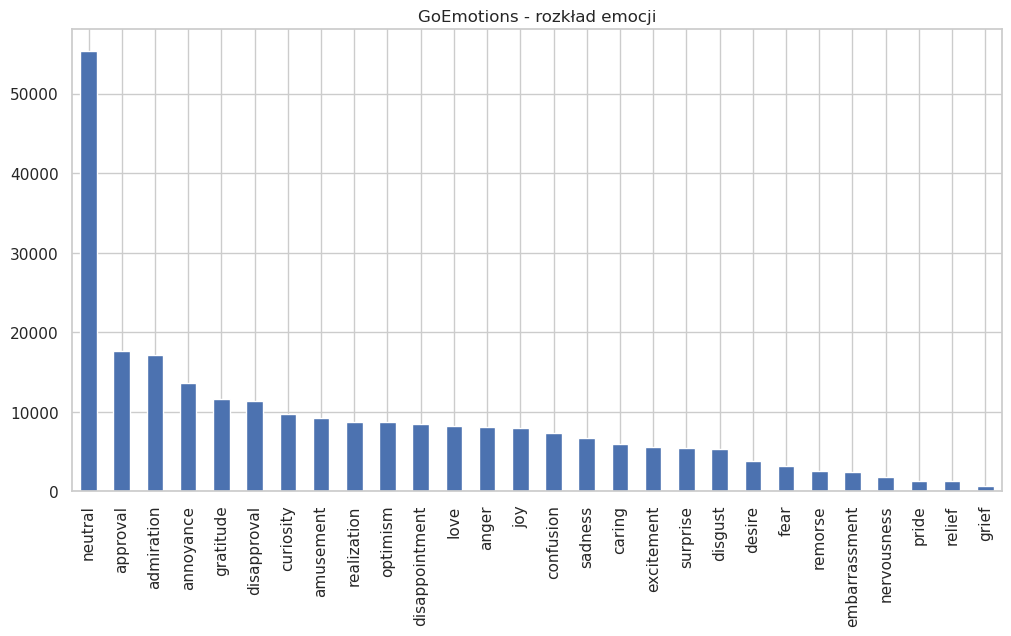

In [5]:
plt.figure()
emotion_distribution.plot(kind="bar")
plt.title("GoEmotions - rozkład emocji")
plt.xticks(rotation=90)
plt.show()

# Combined

Zbior z roznych zrodel, 6 emocji. Wczytuje plik, poprawia nazwy (sad -> sadness, suprise -> surprise), zostawia tylko tekst i emocje.

In [6]:
combined = pd.read_csv("../data/project_data/combined_emotion.csv")

combined["emotion"] = combined["emotion"].replace({"sad": "sadness"})
combined["emotion"] = combined["emotion"].replace({"suprise": "surprise"})

print(combined.shape)
combined.head()

(422746, 2)


,sentence,emotion
0,i just feel really helpless and heavy hearted,fear
1,ive enjoyed being able to slouch about relax a...,sadness
2,i gave up my internship with the dmrg and am f...,fear
3,i dont know i feel so lost,sadness
4,i am a kindergarten teacher and i am thoroughl...,fear


In [7]:
combined_clean = combined[["sentence", "emotion"]].dropna().copy()

combined_clean.head()

,sentence,emotion
0,i just feel really helpless and heavy hearted,fear
1,ive enjoyed being able to slouch about relax a...,sadness
2,i gave up my internship with the dmrg and am f...,fear
3,i dont know i feel so lost,sadness
4,i am a kindergarten teacher and i am thoroughl...,fear


In [8]:
combined_stats = combined_clean["emotion"].value_counts()

print(combined_stats)

emotion
joy         143067
sadness     121187
anger        59317
fear         49649
love         34554
surprise     14972
Name: count, dtype: int64


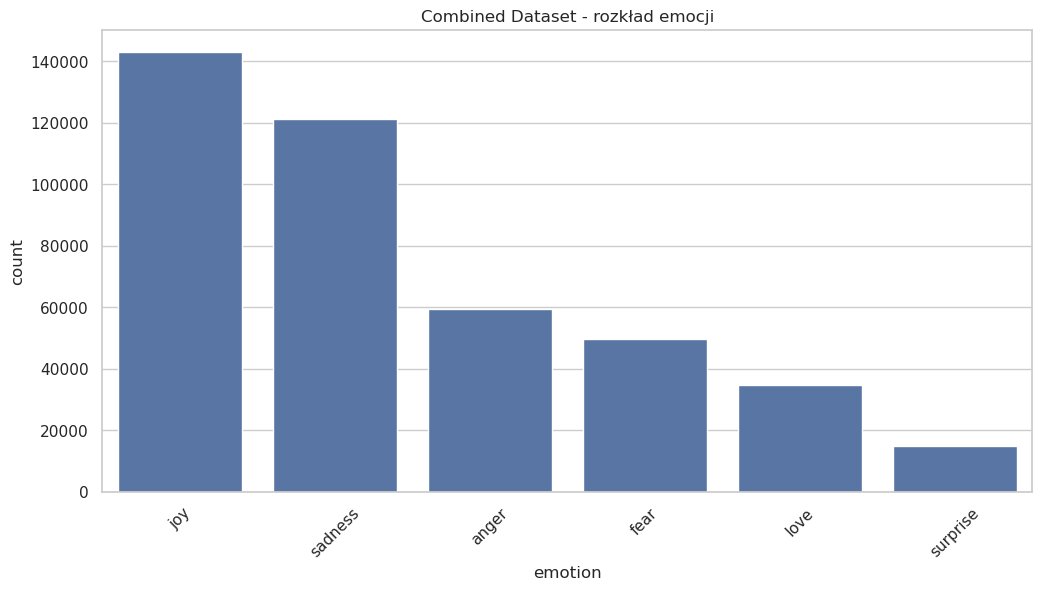

In [9]:
plt.figure()
sns.countplot(data=combined_clean, x="emotion", order=combined_stats.index)
plt.title("Combined Dataset - rozkład emocji")
plt.xticks(rotation=45)
plt.show()

# ISEAR

Zbior z pytaniami o doswiadczenia emocjonalne, 7 emocji. Wczytuje plik CSV, wyciaga kolumny content i emotion, usuwa brakujace wartosci.

In [10]:
isear = pd.read_csv("../data/project_data/ISEAR_dataset_complete.csv")

print(isear.shape)
isear.head()

(7516, 3)


,emotion,content,Unnamed: 2
0,joy,On days when I feel close to my partner and ot...,NaN
1,fear,Every time I imagine that someone I love or I ...,NaN
2,anger,When I had been obviously unjustly treated and...,NaN
3,sadness,When I think about the short time that we live...,NaN
4,disgust,At a gathering I found myself involuntarily si...,NaN


In [11]:
isear_clean = isear[["content", "emotion"]].dropna().copy()

isear_clean.head()

,content,emotion
0,On days when I feel close to my partner and ot...,joy
1,Every time I imagine that someone I love or I ...,fear
2,When I had been obviously unjustly treated and...,anger
3,When I think about the short time that we live...,sadness
4,At a gathering I found myself involuntarily si...,disgust


In [12]:
isear_stats = isear_clean["emotion"].value_counts()

print(isear_stats)

emotion
joy        1092
sadness    1082
anger      1079
fear       1076
shame      1071
disgust    1066
guilt      1050
Name: count, dtype: int64


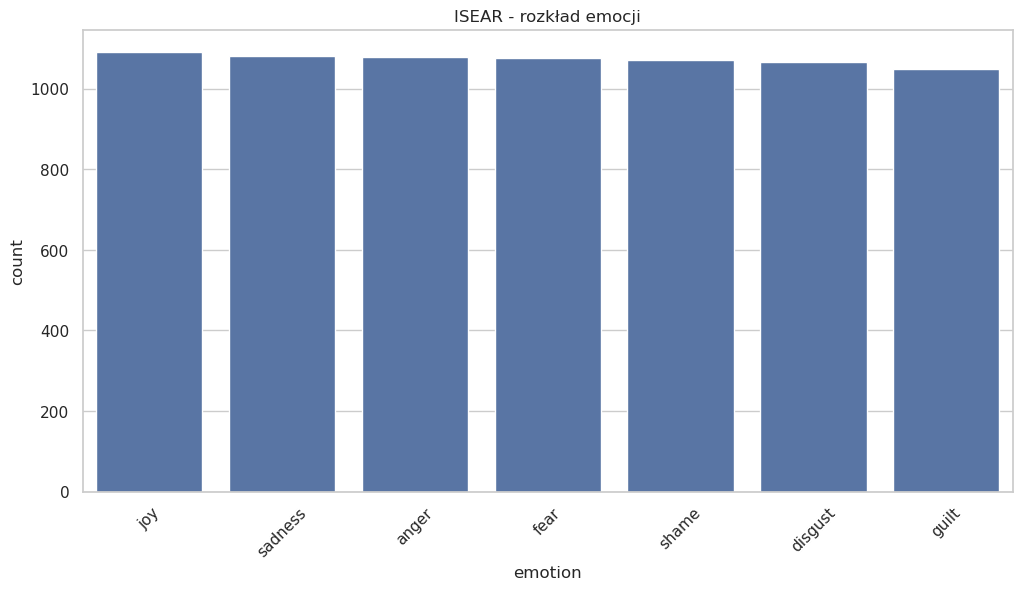

In [13]:
plt.figure()
sns.countplot(data=isear_clean, x="emotion", order=isear_stats.index)
plt.title("ISEAR - rozkład emocji")
plt.xticks(rotation=45)
plt.show()

# Praveen

Zbior z Twittera, emocje w formacie tekst;emocja (srednik jako separator). Wczytuje 3 pliki (train/val/test), laczy w jedna tabele.

In [14]:
# praveen: semicolon-separated, no header
praveen_train = pd.read_csv("../data/project_data/praveen/train.txt", sep=";", names=["sentence", "emotion"])
praveen_val = pd.read_csv("../data/project_data/praveen/val.txt", sep=";", names=["sentence", "emotion"])
praveen_test = pd.read_csv("../data/project_data/praveen/test.txt", sep=";", names=["sentence", "emotion"])

praveen_clean = pd.concat([praveen_train, praveen_val, praveen_test], ignore_index=True)

print(praveen_clean.shape)
praveen_clean.head()

(20000, 2)


,sentence,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [15]:
praveen_stats = praveen_clean["emotion"].value_counts()
print(praveen_stats)

emotion
joy         6761
sadness     5797
anger       2709
fear        2373
love        1641
surprise     719
Name: count, dtype: int64


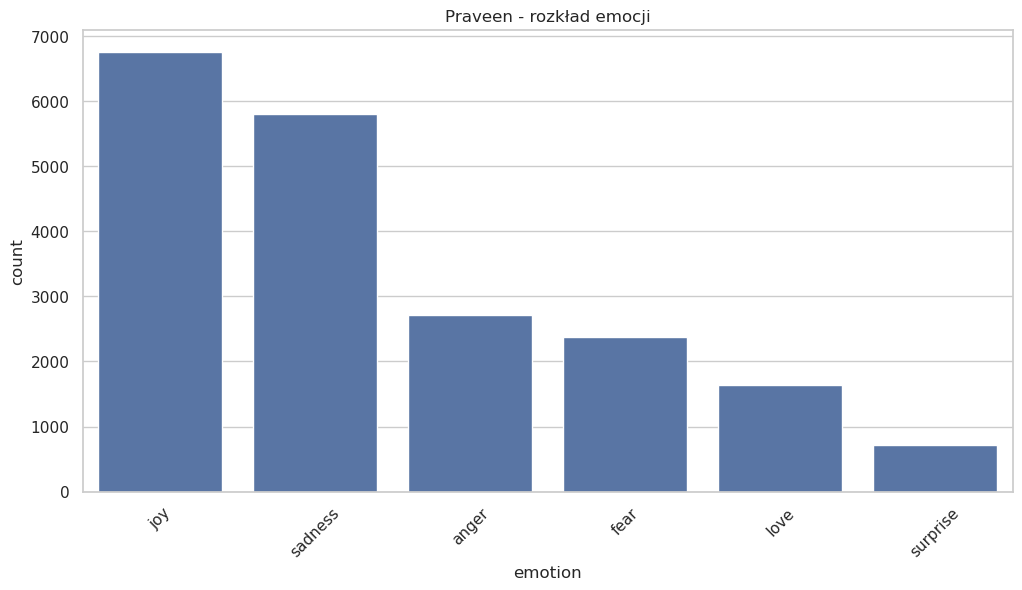

In [16]:
plt.figure()
sns.countplot(data=praveen_clean, x="emotion", order=praveen_stats.index)
plt.title("Praveen - rozkład emocji")
plt.xticks(rotation=45)
plt.show()

# Tripathi

Zbior z Live.ly, format CSV z przecinkami i cudzyslowami. Wczytuje 3 pliki, zmienia nazwy kolumn (text -> sentence, label -> emotion).

In [17]:
# tripathi: comma-separated with quotes, has header
tripathi_train = pd.read_csv("../data/project_data/tripathi/emotion-labels-train.csv")
tripathi_val = pd.read_csv("../data/project_data/tripathi/emotion-labels-val.csv")
tripathi_test = pd.read_csv("../data/project_data/tripathi/emotion-labels-test.csv")

tripathi_clean = pd.concat([tripathi_train, tripathi_val, tripathi_test], ignore_index=True)
tripathi_clean = tripathi_clean.rename(columns={"text": "sentence", "label": "emotion"})

print(tripathi_clean.shape)
tripathi_clean.head()

(7102, 2)


,sentence,emotion
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy
4,I feel so blessed to work with the family that...,joy


In [18]:
tripathi_stats = tripathi_clean["emotion"].value_counts()
print(tripathi_stats)

emotion
fear       2252
anger      1701
joy        1616
sadness    1533
Name: count, dtype: int64


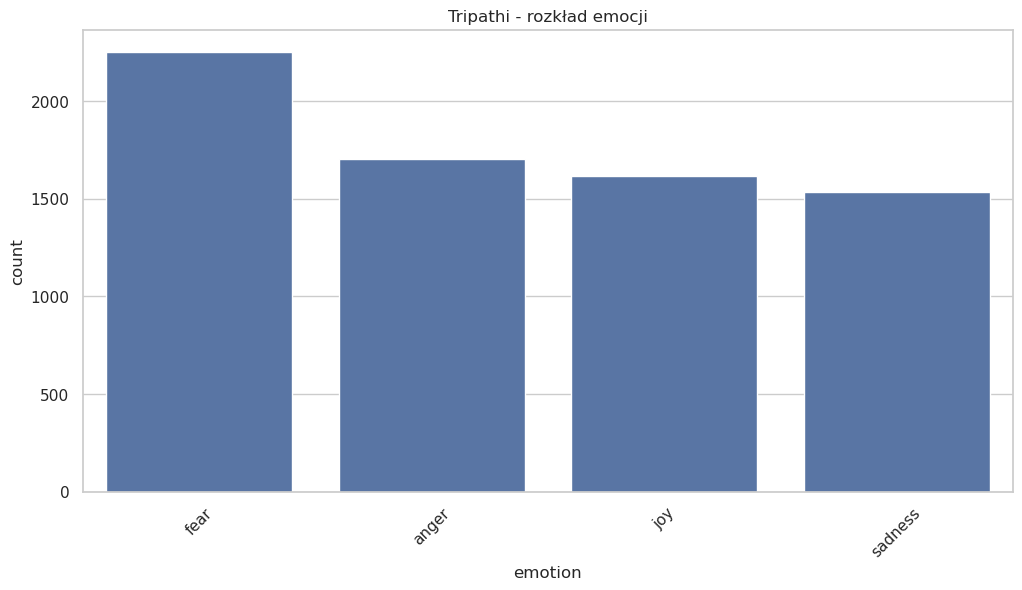

In [19]:
plt.figure()
sns.countplot(data=tripathi_clean, x="emotion", order=tripathi_stats.index)
plt.title("Tripathi - rozkład emocji")
plt.xticks(rotation=45)
plt.show()

# Analiza Razem - porownanie dlugosci tekstow

Liczy srednia dlugosc tekstu w kazdym datasetcie, rysuje rozklad KDE, zestawia tabele z liczba klas i probek. Kazdy dataset ma inny styl wypowiedzi i rozna liczebnosc.

In [20]:
goemotions_clean["length"] = goemotions_clean["text"].apply(len)
combined_clean["length"] = combined_clean["sentence"].apply(len)
isear_clean["length"] = isear_clean["content"].apply(len)
praveen_clean["length"] = praveen_clean["sentence"].apply(len)
tripathi_clean["length"] = tripathi_clean["sentence"].apply(len)

print("GoEmotions avg length:", goemotions_clean["length"].mean())
print("Combined avg length:", combined_clean["length"].mean())
print("ISEAR avg length:", isear_clean["length"].mean())
print("Praveen avg length:", praveen_clean["length"].mean())
print("Tripathi avg length:", tripathi_clean["length"].mean())

GoEmotions avg length: 69.41395189929456
Combined avg length: 97.03398021507005
ISEAR avg length: 116.78485896753592
Praveen avg length: 96.67005
Tripathi avg length: 95.25091523514503


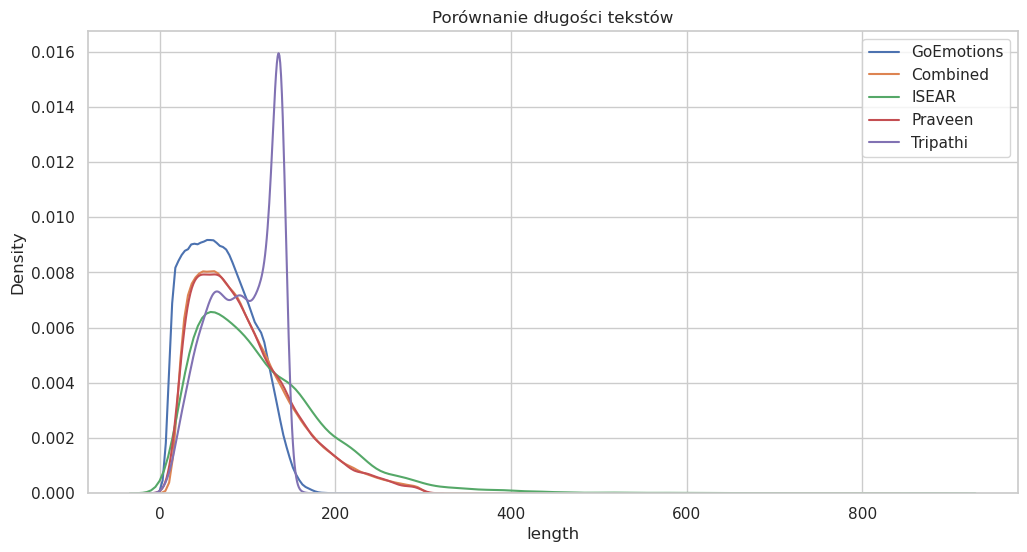

In [21]:
plt.figure()

sns.kdeplot(goemotions_clean["length"], label="GoEmotions")
sns.kdeplot(combined_clean["length"], label="Combined")
sns.kdeplot(isear_clean["length"], label="ISEAR")
sns.kdeplot(praveen_clean["length"], label="Praveen")
sns.kdeplot(tripathi_clean["length"], label="Tripathi")

plt.legend()
plt.title("Porównanie długości tekstów")
plt.show()

In [22]:
comparison = pd.DataFrame({
    "dataset": ["GoEmotions", "Combined", "ISEAR", "Praveen", "Tripathi"],
    "num_classes": [
        len(emotion_cols),
        combined_clean["emotion"].nunique(),
        isear_clean["emotion"].nunique(),
        praveen_clean["emotion"].nunique(),
        tripathi_clean["emotion"].nunique()
    ],
    "num_samples": [
        len(goemotions_clean),
        len(combined_clean),
        len(isear_clean),
        len(praveen_clean),
        len(tripathi_clean)
    ]
})

comparison

,dataset,num_classes,num_samples
0,GoEmotions,28,207814
1,Combined,6,422746
2,ISEAR,7,7516
3,Praveen,6,20000
4,Tripathi,4,7102


In [23]:
goemotions_clean.to_csv("../data/project_data/goemotions_clean.csv", index=False)
combined_clean.to_csv("../data/project_data/combined_clean.csv", index=False)
isear_clean.to_csv("../data/project_data/isear_clean.csv", index=False)
praveen_clean.to_csv("../data/project_data/praveen_clean.csv", index=False)
tripathi_clean.to_csv("../data/project_data/tripathi_clean.csv", index=False)

# Jakie emocje wystepuja w ktorych datasetach

Tworzy macierz obecnosci (1 = jest, 0 = brak) dla kazdej emocji we wszystkich 5 zbiorach. Heatmapa pokazuje, ktore emocje sa wspolne, a ktore wystepuja tylko w jednym zrodle.

In [24]:
# GoEmotions (kolumny emocji)
go_classes = list(emotion_cols)

# Combined
combined_classes = combined_clean["emotion"].unique().tolist()

# ISEAR
isear_classes = isear_clean["emotion"].unique().tolist()

# Praveen
praveen_classes = praveen_clean["emotion"].unique().tolist()

# Tripathi
tripathi_classes = tripathi_clean["emotion"].unique().tolist()

all_classes = sorted(set(go_classes + combined_classes + isear_classes + praveen_classes + tripathi_classes))

print("Liczba wszystkich unikalnych klas:", len(all_classes))

Liczba wszystkich unikalnych klas: 30


In [25]:
presence = pd.DataFrame(index=all_classes)

presence["GoEmotions"] = [1 if c in go_classes else 0 for c in all_classes]
presence["Combined"] = [1 if c in combined_classes else 0 for c in all_classes]
presence["ISEAR"] = [1 if c in isear_classes else 0 for c in all_classes]
presence["Praveen"] = [1 if c in praveen_classes else 0 for c in all_classes]
presence["Tripathi"] = [1 if c in tripathi_classes else 0 for c in all_classes]

presence.head(20)

,GoEmotions,Combined,ISEAR,Praveen,Tripathi
admiration,1,0,0,0,0
amusement,1,0,0,0,0
anger,1,1,1,1,1
annoyance,1,0,0,0,0
approval,1,0,0,0,0
caring,1,0,0,0,0
confusion,1,0,0,0,0
curiosity,1,0,0,0,0
desire,1,0,0,0,0
disappointment,1,0,0,0,0


In [26]:
# emocje obecne we wszystkich 5 datasetach
common_mask = (presence["GoEmotions"] == 1) & \
              (presence["Combined"] == 1) & \
              (presence["ISEAR"] == 1) & \
              (presence["Praveen"] == 1) & \
              (presence["Tripathi"] == 1)

# maska: True tylko tam gdzie emocja jest we wszystkich datasetach
common_cells = presence.eq(1) & presence.all(axis=1).values[:, None]

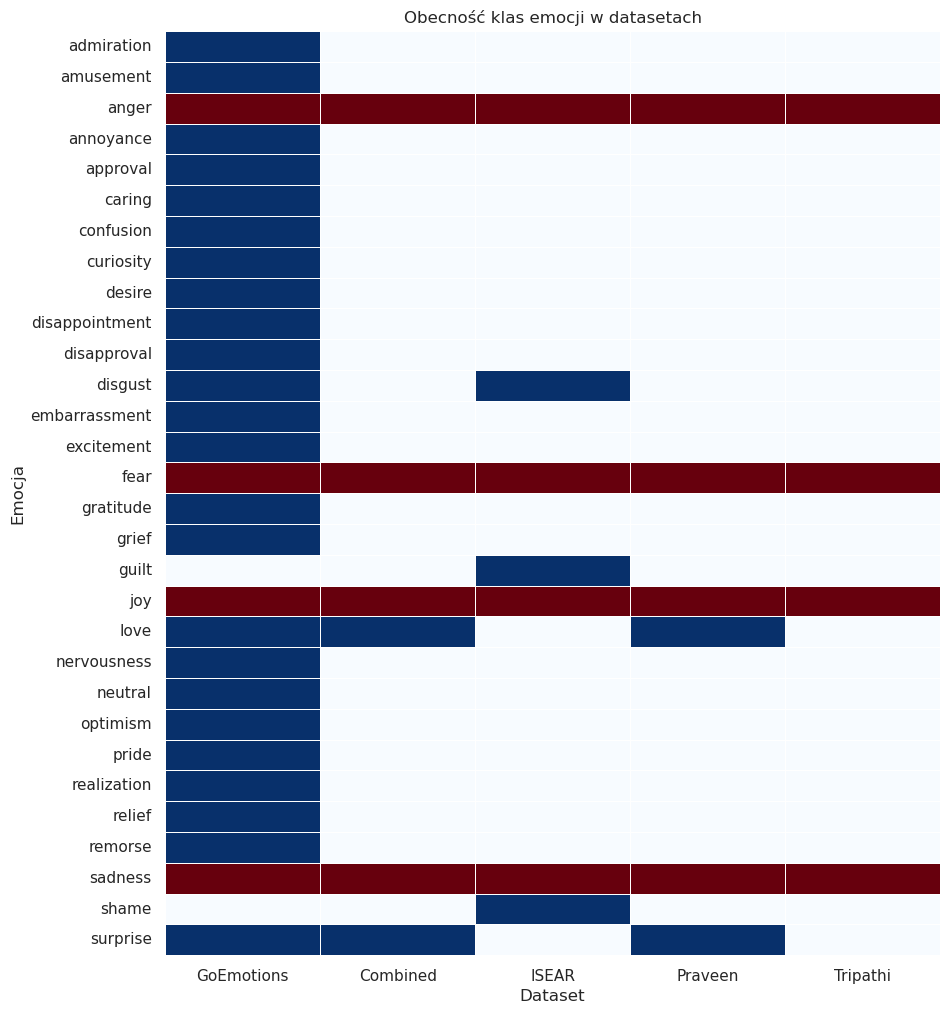

In [27]:
plt.figure(figsize=(10, 12))

# bazowa heatmapa (niebieska)
sns.heatmap(presence, cmap="Blues", cbar=False, linewidths=0.5)

# NAŁOŻENIE czerwonego koloru tylko na wspólne emocje
sns.heatmap(
    presence,
    cmap="Reds",
    vmin=0, vmax=1,   # <-- KLUCZOWE
    cbar=False,
    linewidths=0.5,
    mask=~common_cells, 
)

plt.title("Obecność klas emocji w datasetach")
plt.xlabel("Dataset")
plt.ylabel("Emocja")

plt.show()

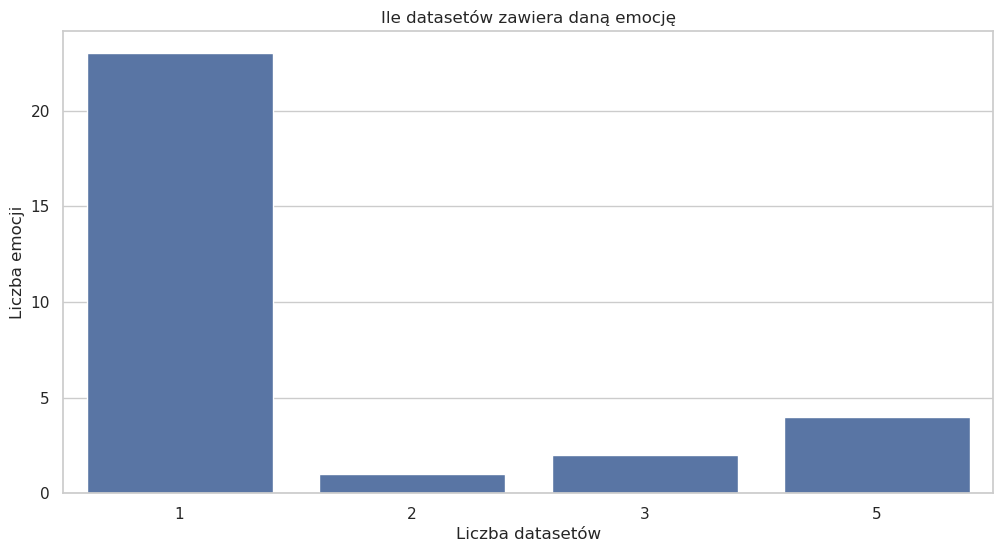

In [28]:
presence["count_datasets"] = presence.sum(axis=1)

plt.figure()

sns.countplot(x="count_datasets", data=presence)

plt.title("Ile datasetów zawiera daną emocję")
plt.xlabel("Liczba datasetów")
plt.ylabel("Liczba emocji")

plt.show()

In [29]:
only_one = presence[presence["count_datasets"] == 1].index.tolist()
in_two = presence[presence["count_datasets"] == 2].index.tolist()
in_all = presence[presence["count_datasets"] == 5].index.tolist()

print("Tylko w jednym datasetcie:", only_one)
print("\nW dwóch datasetach:", in_two)
print("\nWe wszystkich:", in_all)

Tylko w jednym datasetcie: ['admiration', 'amusement', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'embarrassment', 'excitement', 'gratitude', 'grief', 'guilt', 'nervousness', 'neutral', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'shame']

W dwóch datasetach: ['disgust']

We wszystkich: ['anger', 'fear', 'joy', 'sadness']


# Normalizacja nazw emocji

Niektore datasety maja alternatywne nazwy (np. happiness zamiast joy, sad zamiast sadness). Mapujemy je do wspolnego formatu, zeby moc porownywac i laczyc dane.

In [30]:
mapping = {
    "happiness": "joy",
    "sad": "sadness",
    "fearful": "fear",
    "angry": "anger"
}

In [31]:
combined_clean["emotion_norm"] = combined_clean["emotion"].replace(mapping)
isear_clean["emotion_norm"] = isear_clean["emotion"].replace(mapping)
praveen_clean["emotion_norm"] = praveen_clean["emotion"].replace(mapping)
tripathi_clean["emotion_norm"] = tripathi_clean["emotion"].replace(mapping)

# Redukcja do 4 wspolnych emocji (joy, sadness, anger, fear)

Z kazdego datasetu wybieramy tylko joy, sadness, anger, fear - to jedyne emocje wystepujace we wszystkich 5 zbiorach. GoEmotions wymaga dodatkowego przejscia z multi-label na single-label (usuwamy wiersze z wiecej niz jedna emocja).

In [32]:
target_emotions = ["joy", "sadness", "anger", "fear"]

# --- GoEmotions: multi-label -> single-label ---
emotion_cols_in_df = [c for c in goemotions_clean.columns if c not in ("text", "length")]
single = goemotions_clean[emotion_cols_in_df].sum(axis=1) == 1
go_single = goemotions_clean[single].copy()
go_single["emotion"] = go_single[emotion_cols_in_df].idxmax(axis=1)

go_red = go_single[go_single["emotion"].isin(target_emotions)].copy()
go_red = go_red.rename(columns={"text": "sentence"})
go_red = go_red[["sentence", "emotion", "length"]]

# --- Combined ---
combined_red = combined_clean[combined_clean["emotion"].isin(target_emotions)].copy()
combined_red = combined_red[["sentence", "emotion", "length"]]

# --- ISEAR ---
isear_red = isear_clean[isear_clean["emotion"].isin(target_emotions)].copy()
isear_red = isear_red.rename(columns={"content": "sentence"})
isear_red = isear_red[["sentence", "emotion", "length"]]

# --- Praveen ---
praveen_red = praveen_clean[praveen_clean["emotion"].isin(target_emotions)].copy()
praveen_red = praveen_red[["sentence", "emotion", "length"]]

# --- Tripathi ---
tripathi_red = tripathi_clean[tripathi_clean["emotion"].isin(target_emotions)].copy()
tripathi_red = tripathi_red[["sentence", "emotion", "length"]]

print("Rozmiary po redukcji:\n")
print(f"GoEmotions: {len(go_red)}/{len(goemotions_clean)}")
print(f"Combined:   {len(combined_red)}/{len(combined_clean)}")
print(f"ISEAR:      {len(isear_red)}/{len(isear_clean)}")
print(f"Praveen:    {len(praveen_red)}/{len(praveen_clean)}")
print(f"Tripathi:   {len(tripathi_red)}/{len(tripathi_clean)}")

Rozmiary po redukcji:

GoEmotions: 15136/207814
Combined:   373220/422746
ISEAR:      4329/7516
Praveen:    17640/20000
Tripathi:   7102/7102


--- GoEmotions ---
emotion
anger      5202
joy        4329
sadness    3827
fear       1778

--- Combined ---
emotion
joy        143067
sadness    121187
anger       59317
fear        49649

--- ISEAR ---
emotion
joy        1092
sadness    1082
anger      1079
fear       1076

--- Praveen ---
emotion
joy        6761
sadness    5797
anger      2709
fear       2373

--- Tripathi ---
emotion
fear       2252
anger      1701
joy        1616
sadness    1533



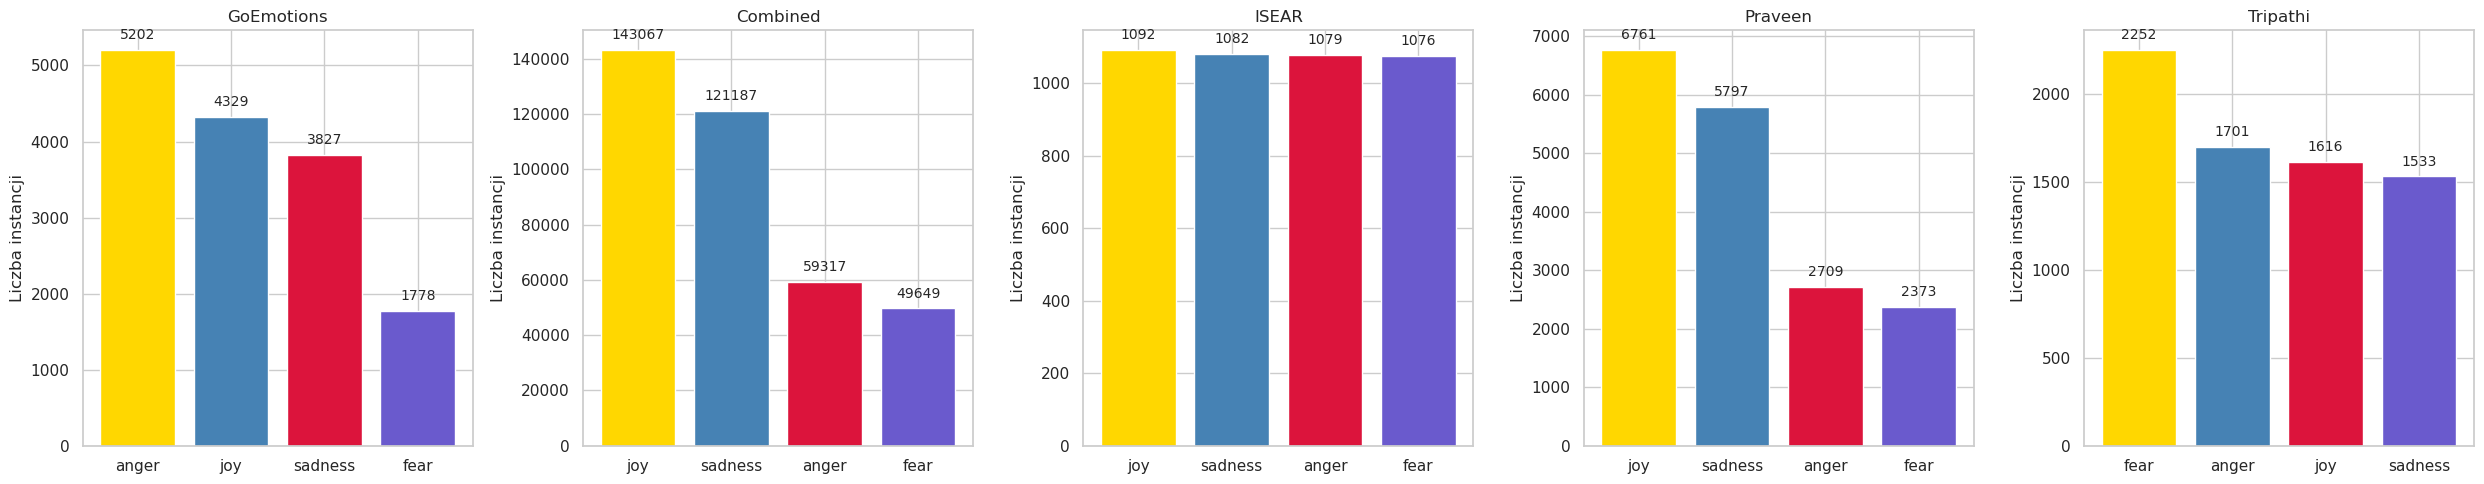

In [33]:
datasets = [("GoEmotions", go_red), ("Combined", combined_red), ("ISEAR", isear_red), ("Praveen", praveen_red), ("Tripathi", tripathi_red)]

for name, df in datasets:
    print(f"--- {name} ---")
    print(df["emotion"].value_counts().to_string())
    print()

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, (name, df) in zip(axes, datasets):
    counts = df["emotion"].value_counts()
    colors = ["#ffd700", "#4682b4", "#dc143c", "#6a5acd"]
    bars = ax.bar(counts.index, counts.values, color=colors)
    ax.set_title(name)
    ax.set_ylabel("Liczba instancji")
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts.values)*0.02,
                str(v), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# Zapis do plikow

Kazdy zredukowany dataset zapisujemy jako osobny plik CSV w folderze reduced/. Gotowe do dalszej analizy lub trenowania modelu.

In [34]:
import os

os.makedirs("../data/project_data/reduced", exist_ok=True)

go_red.to_csv("../data/project_data/reduced/goemotions_red.csv", index=False)
combined_red.to_csv("../data/project_data/reduced/combined_red.csv", index=False)
isear_red.to_csv("../data/project_data/reduced/isear_red.csv", index=False)
praveen_red.to_csv("../data/project_data/reduced/praveen_red.csv", index=False)
tripathi_red.to_csv("../data/project_data/reduced/tripathi_red.csv", index=False)

print("Zapisano do folderu ../data/project_data/reduced/")

Zapisano do folderu ../data/project_data/reduced/
